# 07 — GradientSHAP Band Importance Analysis

Compute per-band SHAP values using GradientSHAP to understand which input
features the model relies on for wetland classification.

**Outputs:**
- Per-band importance bar plot (mean |SHAP|)
- Per-class band importance grouped bar plot
- SHAP summary (beeswarm) plot

In [1]:
# Install shap if needed (conda-forge recommended for conda environments)
try:
    import shap
except ImportError:
    import subprocess
    subprocess.check_call(["conda", "install", "-y", "-c", "conda-forge", "shap"])
    import shap

print(f"SHAP version: {shap.__version__}")

/opt/miniconda3/envs/wetland-cnn/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP version: 0.50.0


In [ ]:
import json
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
import importlib.util
import sys
import random

# ── Configuration ────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd().parent.parent  # adjust if needed

MODEL_PATH   = PROJECT_ROOT / "Models" / "best_multiclass_unet-v5.ckpt"
STATS_PATH   = PROJECT_ROOT / "Data" / "Training_Data" / "normalization_stats.json"
PATCHES_DIR  = PROJECT_ROOT / "Data" / "Training_Data" / "R_Patches"
OUTPUT_DIR   = PROJECT_ROOT / "Models"  # saved figures go here

BASE_FILTERS = 64
DEPTH        = 4
SEED         = 420

# ASPP configuration (must match the checkpoint being loaded)
USE_ASPP     = False
ASPP_RATES   = (6, 12, 18)

# SHAP parameters
N_BACKGROUND = 50    # number of training patches for background
N_TEST       = 20    # number of test patches to explain
CROP_SIZE    = 128   # center-crop to reduce memory (None = full patch) Use 128 to reduce memory usage

print(f"Project root: {PROJECT_ROOT}")
print(f"Model:        {MODEL_PATH}")
print(f"Patches:      {PATCHES_DIR}")

In [3]:
# ── Import pipeline modules ──────────────────────────────────────
script_dir = PROJECT_ROOT / "Python_Code_Analysis" / "DL_Pipeline_v2"

if str(script_dir) not in sys.path:
    sys.path.insert(0, str(script_dir))

import dl_02_dataset as _dataset
import dl_03_unet_model as _model
import dl_05_evaluate as _evaluate

create_data_splits   = _dataset.create_data_splits
WetlandPatchDataset  = _dataset.WetlandPatchDataset
load_model           = _evaluate.load_model
get_device           = _model.get_device

In [ ]:
# ── Load stats & model ───────────────────────────────────────────
with open(STATS_PATH) as f:
    stats = json.load(f)

IN_CHANNELS   = stats["in_channels"]
CLASS_NAMES   = stats["class_names"]
NUM_CLASSES   = len(CLASS_NAMES)
PREDICTOR_NAMES = stats["predictor_names"]
NORMALIZATION = stats["normalization"]

device = get_device()
model  = load_model(MODEL_PATH, device, IN_CHANNELS, NUM_CLASSES, BASE_FILTERS, DEPTH,
                    use_aspp=USE_ASPP, aspp_rates=ASPP_RATES)

print(f"\nClasses ({NUM_CLASSES}): {CLASS_NAMES}")
print(f"Predictor bands ({len(PREDICTOR_NAMES)}): {PREDICTOR_NAMES}")
print(f"Expanded channels: {IN_CHANNELS}")

In [5]:
# ── Build channel → band mapping ────────────────────────────────
# Maps each of the 35 expanded channels back to its parent band name.
# One-hot bands (Geomorph_local) get multiple channel entries.

channel_to_band = []   # list of length IN_CHANNELS
band_channel_ranges = {}  # band_name -> (start, end) indices

ch = 0
for band_name in PREDICTOR_NAMES:
    norm_cfg = NORMALIZATION[band_name]
    start = ch
    if norm_cfg["method"] == "one_hot":
        n = norm_cfg["num_classes"]
        channel_to_band.extend([band_name] * n)
        ch += n
    else:
        channel_to_band.append(band_name)
        ch += 1
    band_channel_ranges[band_name] = (start, ch)

assert len(channel_to_band) == IN_CHANNELS, (
    f"Expected {IN_CHANNELS} channels, got {len(channel_to_band)}"
)

print(f"Channel mapping built: {len(channel_to_band)} channels → {len(PREDICTOR_NAMES)} bands")
for name, (s, e) in band_channel_ranges.items():
    n = e - s
    if n > 1:
        print(f"  {name}: channels {s}-{e-1} ({n} channels, one-hot)")

Channel mapping built: 18 channels → 18 bands


In [6]:
# ── Load background & test data ─────────────────────────────────
train_files, _, test_files = create_data_splits(PATCHES_DIR, seed=SEED)

# Subsample
random.seed(SEED)
bg_files   = random.sample(train_files, min(N_BACKGROUND, len(train_files)))
test_files = random.sample(test_files,  min(N_TEST, len(test_files)))

bg_dataset   = WetlandPatchDataset(bg_files,   STATS_PATH, augment=False)
test_dataset = WetlandPatchDataset(test_files, STATS_PATH, augment=False)

def center_crop(tensor, size):
    """Center-crop a (C, H, W) tensor to (C, size, size)."""
    if size is None:
        return tensor
    _, h, w = tensor.shape
    y0 = (h - size) // 2
    x0 = (w - size) // 2
    return tensor[:, y0:y0+size, x0:x0+size]

def load_tensors(dataset, crop_size):
    """Load all patches from dataset into a single tensor."""
    tensors = []
    for i in range(len(dataset)):
        X, _ = dataset[i]
        X = center_crop(X, crop_size)
        tensors.append(X)
    return torch.stack(tensors)

print(f"\nLoading {len(bg_dataset)} background patches...")
background = load_tensors(bg_dataset, CROP_SIZE).to(device)

print(f"Loading {len(test_dataset)} test patches...")
test_data = load_tensors(test_dataset, CROP_SIZE).to(device)

print(f"Background shape: {background.shape}")
print(f"Test data shape:  {test_data.shape}")

Data split (seed=420):
  Train: 58 patches (69.0%)
  Val:   12 patches (14.3%)
  Test:  14 patches (16.7%)

Loading 50 background patches...
Loading 14 test patches...
Background shape: torch.Size([50, 18, 128, 128])
Test data shape:  torch.Size([14, 18, 128, 128])


In [7]:
# ── Run GradientSHAP ────────────────────────────────────────────
# GradientExplainer computes SHAP values using expected gradients
# (an approximation of Shapley values via integrated gradients
# with random reference samples).
#
# The UNet outputs (batch, num_classes, H, W) but GradientSHAP
# requires scalar outputs. We wrap the model to average logits
# over the spatial dimensions → (batch, num_classes).

class SpatialAvgWrapper(torch.nn.Module):
    """Wrap a segmentation model to return spatially-averaged logits."""
    def __init__(self, seg_model):
        super().__init__()
        self.seg_model = seg_model

    def forward(self, x):
        logits = self.seg_model(x)          # (B, C, H, W)
        return logits.mean(dim=(-2, -1))    # (B, C)

wrapped_model = SpatialAvgWrapper(model)
wrapped_model.eval()

explainer = shap.GradientExplainer(wrapped_model, background)

print(f"Computing SHAP values for {test_data.shape[0]} patches...")
print("(This may take several minutes depending on patch/crop size.)")

# Returns a list of arrays, one per output class
# Each array has shape (N_test, C, H, W)
shap_values = explainer.shap_values(test_data)

print(f"Done. SHAP values: {len(shap_values)} classes, each shape {shap_values[0].shape}")

Computing SHAP values for 14 patches...
(This may take several minutes depending on patch/crop size.)
Done. SHAP values: 14 classes, each shape (18, 128, 128, 4)


In [8]:
# ── Aggregate SHAP values: channel → band level ─────────────────
# For each output class:
#   1. Take |SHAP| per channel
#   2. Average over spatial dimensions (H, W) → per-sample, per-channel
#   3. Sum channels belonging to the same band (e.g. Geomorph one-hot)
#   4. Average over samples → per-band importance for that class
#
# SHAP 0.50 with GradientExplainer returns a list of N arrays,
# each with shape (C_input, H, W, num_output_classes).
# We stack to (N, C_input, H, W, num_classes) then rearrange to
# (num_classes, N, C_input, H, W) for consistent downstream code.

sv = np.array(shap_values)  # (N, C_input, H, W, num_classes)
print(f"Raw stacked shape: {sv.shape}")

# Rearrange to (num_classes, N, C_input, H, W)
shap_array = sv.transpose(4, 0, 1, 2, 3)
print(f"Rearranged shape:  {shap_array.shape}  (num_classes, N, C_input, H, W)")

# Mean |SHAP| over spatial dims → (num_classes, N, C_input)
shap_abs_spatial = np.abs(shap_array).mean(axis=(-2, -1))

# Aggregate channels → bands
n_bands = len(PREDICTOR_NAMES)

# (num_classes, N, n_bands)
shap_band = np.zeros((NUM_CLASSES, shap_abs_spatial.shape[1], n_bands))

for b_idx, band_name in enumerate(PREDICTOR_NAMES):
    start, end = band_channel_ranges[band_name]
    shap_band[:, :, b_idx] = shap_abs_spatial[:, :, start:end].sum(axis=-1)

# Mean over samples → (num_classes, n_bands)
importance_per_class = shap_band.mean(axis=1)

# Overall importance: mean across classes → (n_bands,)
importance_overall = importance_per_class.mean(axis=0)

print("Aggregated SHAP values to band level.")
print(f"Shape per class: {importance_per_class.shape}")
print(f"Overall shape:   {importance_overall.shape}")

Raw stacked shape: (14, 18, 128, 128, 4)
Rearranged shape:  (4, 14, 18, 128, 128)  (num_classes, N, C_input, H, W)
Aggregated SHAP values to band level.
Shape per class: (4, 18)
Overall shape:   (18,)


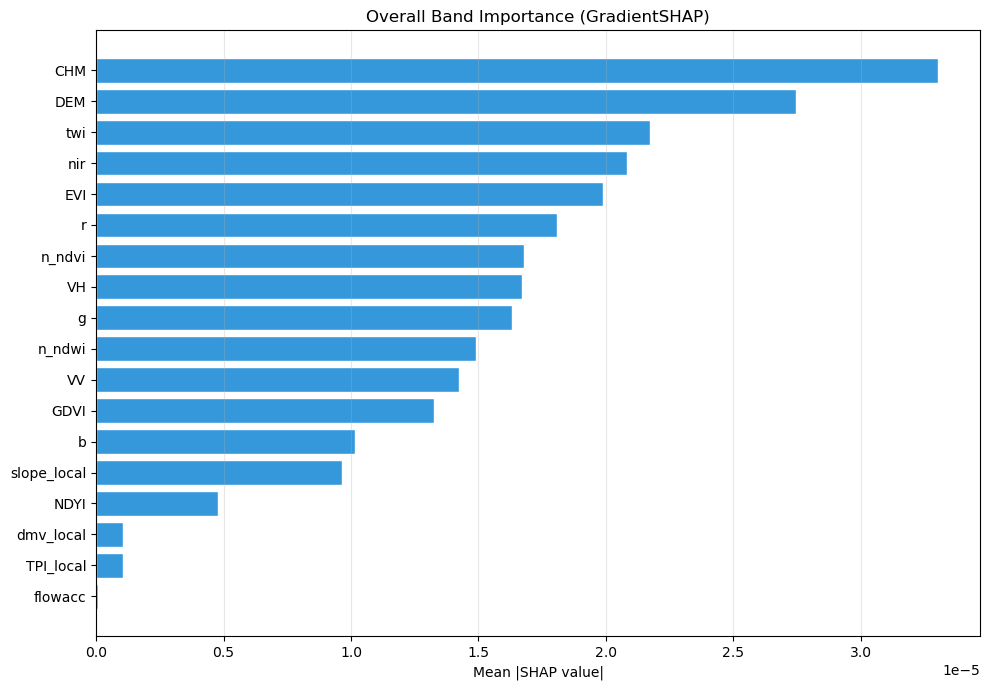

Saved to /Users/Anthony/Data and Analysis Local/NYS_Wetlands_DL/Models/shap_band_importance.png


In [9]:
# ── Plot 1: Overall per-band importance ──────────────────────────
sort_idx = np.argsort(importance_overall)[::-1]
sorted_names = [PREDICTOR_NAMES[i] for i in sort_idx]
sorted_vals  = importance_overall[sort_idx]

fig, ax = plt.subplots(figsize=(10, 7))
y_pos = np.arange(len(sorted_names))
ax.barh(y_pos, sorted_vals, color="#3498db", edgecolor="white")
ax.set_yticks(y_pos)
ax.set_yticklabels(sorted_names)
ax.invert_yaxis()
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("Overall Band Importance (GradientSHAP)")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "shap_band_importance.png", dpi=150)
plt.show()
print(f"Saved to {OUTPUT_DIR / 'shap_band_importance.png'}")

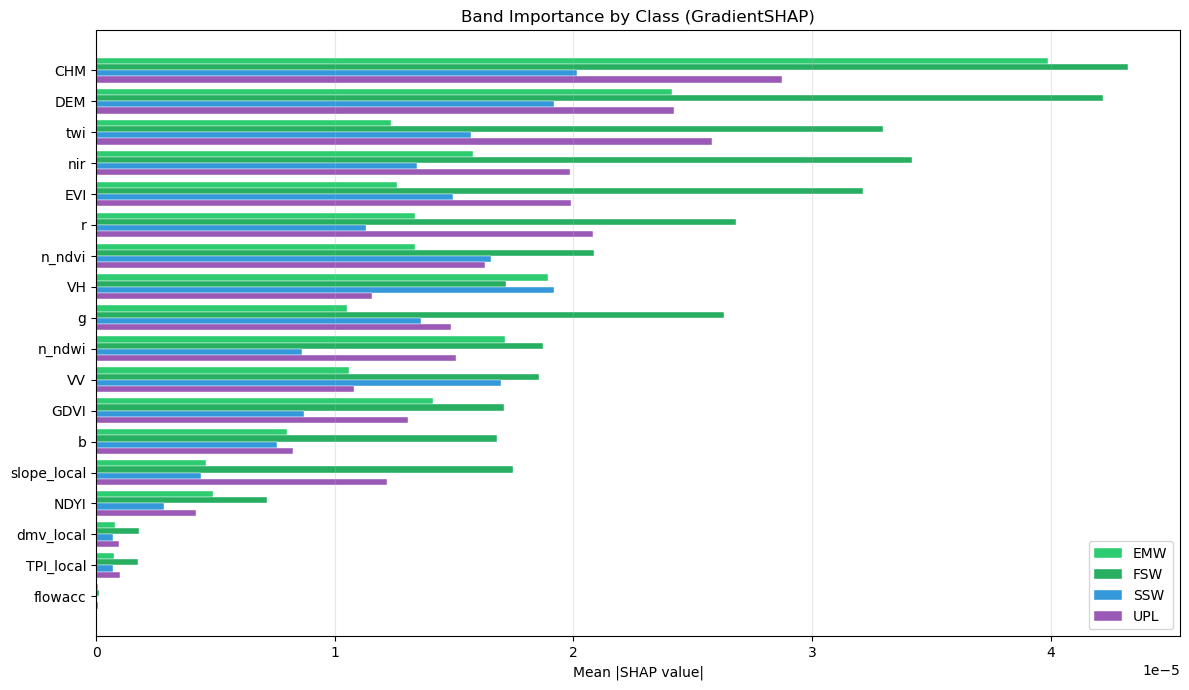

Saved to /Users/Anthony/Data and Analysis Local/NYS_Wetlands_DL/Models/shap_band_importance_by_class.png


In [10]:
# ── Plot 2: Per-class band importance (grouped bar chart) ────────
all_colors = ["#2ecc71", "#27ae60", "#3498db", "#9b59b6", "#95a5a6"]
colors = all_colors[:NUM_CLASSES]

fig, ax = plt.subplots(figsize=(12, 7))
bar_width = 0.8 / NUM_CLASSES
y_pos = np.arange(n_bands)

# Sort by overall importance
for c_idx, class_name in enumerate(CLASS_NAMES):
    vals = importance_per_class[c_idx][sort_idx]
    offset = (c_idx - NUM_CLASSES / 2 + 0.5) * bar_width
    ax.barh(y_pos + offset, vals, bar_width,
            label=class_name, color=colors[c_idx], edgecolor="white", linewidth=0.3)

ax.set_yticks(y_pos)
ax.set_yticklabels(sorted_names)
ax.invert_yaxis()
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("Band Importance by Class (GradientSHAP)")
ax.legend(loc="lower right")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "shap_band_importance_by_class.png", dpi=150)
plt.show()
print(f"Saved to {OUTPUT_DIR / 'shap_band_importance_by_class.png'}")

/var/folders/zl/0vy_zjm14sj4lycq01nznh0m0000gn/T/ipykernel_4224/1859838487.py:20: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


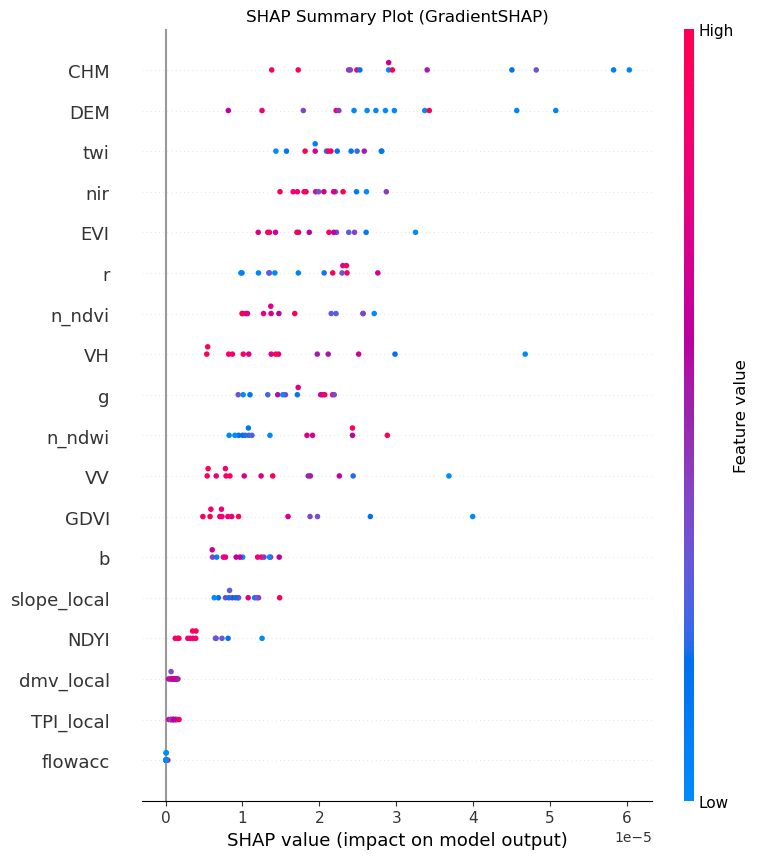

Saved to /Users/Anthony/Data and Analysis Local/NYS_Wetlands_DL/Models/shap_summary_plot.png


In [11]:
# ── Plot 3: SHAP summary (beeswarm) plot ────────────────────────
# Reshape band-level SHAP and feature values for shap.summary_plot.
# We average across classes to get a single SHAP value per band per
# sample, and compute the corresponding mean feature value per band.

# shap_band: (num_classes, N, n_bands) → mean over classes → (N, n_bands)
shap_band_mean = shap_band.mean(axis=0)

# Compute band-level feature values from test_data
test_np = test_data.cpu().numpy()  # (N, C, H, W)

# Average each band's channels spatially → (N, n_bands)
feature_vals = np.zeros((test_np.shape[0], n_bands))
for b_idx, band_name in enumerate(PREDICTOR_NAMES):
    start, end = band_channel_ranges[band_name]
    # Mean over channels and spatial dims
    feature_vals[:, b_idx] = test_np[:, start:end, :, :].mean(axis=(1, 2, 3))

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_band_mean,
    features=feature_vals,
    feature_names=PREDICTOR_NAMES,
    show=False,
    max_display=n_bands,
)
plt.title("SHAP Summary Plot (GradientSHAP)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "shap_summary_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {OUTPUT_DIR / 'shap_summary_plot.png'}")

In [12]:
# ── Print ranked importance table ────────────────────────────────
print(f"{'Rank':<6} {'Band':<20} {'Mean |SHAP|':>12}")
print("-" * 40)
for rank, idx in enumerate(sort_idx, 1):
    print(f"{rank:<6} {PREDICTOR_NAMES[idx]:<20} {importance_overall[idx]:>12.6f}")

print(f"\nPer-class breakdown:")
print(f"{'Band':<20}", end="")
for name in CLASS_NAMES:
    print(f"{name:>12}", end="")
print()
print("-" * (20 + 12 * NUM_CLASSES))
for idx in sort_idx:
    print(f"{PREDICTOR_NAMES[idx]:<20}", end="")
    for c in range(NUM_CLASSES):
        print(f"{importance_per_class[c, idx]:>12.6f}", end="")
    print()

Rank   Band                  Mean |SHAP|
----------------------------------------
1      CHM                      0.000033
2      DEM                      0.000027
3      twi                      0.000022
4      nir                      0.000021
5      EVI                      0.000020
6      r                        0.000018
7      n_ndvi                   0.000017
8      VH                       0.000017
9      g                        0.000016
10     n_ndwi                   0.000015
11     VV                       0.000014
12     GDVI                     0.000013
13     b                        0.000010
14     slope_local              0.000010
15     NDYI                     0.000005
16     dmv_local                0.000001
17     TPI_local                0.000001
18     flowacc                  0.000000

Per-class breakdown:
Band                         EMW         FSW         SSW         UPL
--------------------------------------------------------------------
CHM                 